In [2]:
!pip install osmnx networkx ortools numpy matplotlib scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/23.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/23.9 MB 4.8 MB/s eta 0:00:05
   --- ------------------------------------ 1.8/23.9 MB 4.6 MB/s eta 0:00:05
   ---- ----------------------------------- 2.9/23.9 MB 4.5 MB/s eta 0:00:05
   ----- ---------------------------------- 3.4/23.9 MB 4.4 MB/s eta 0:00:05
   ------ --------------------------------- 3.9/23.9 MB 4.0 MB/s eta 0:00:06
   ------- -------------------------------- 4.5/23.9 MB 3.7 MB/s eta 0:00:06
   --------- ------------------------------ 5.8/23.9 MB 4.0 MB/s eta 0:00:05
   ----------- ---------

In [1]:
import osmnx as ox
import networkx as nx

# Select Bengaluru area
place_name = "Indiranagar, Bangalore, India"

# Download road network
G = ox.graph_from_place(place_name, network_type='drive')

G = ox.convert.to_undirected(G)

print("Number of nodes:", len(G.nodes))
print("Number of edges:", len(G.edges))

Number of nodes: 327
Number of edges: 466


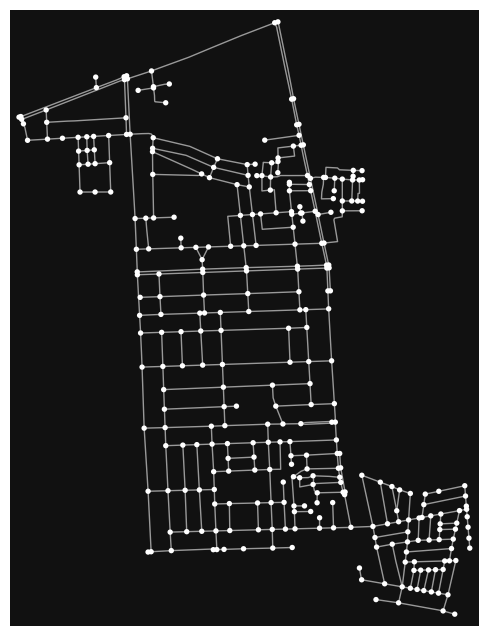

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
ox.plot_graph(G)

In [3]:
# Warehouse coordinates (you can change)
warehouse_coords = (12.9716, 77.5946)

# Convert to nearest graph node
warehouse_node = ox.distance.nearest_nodes(
    G,
    warehouse_coords[1],
    warehouse_coords[0]
)

print("Warehouse node:", warehouse_node)

Warehouse node: 11909580134


In [4]:
import random

# -------------------------------
# STEP 2: Generate clustered orders
# -------------------------------

def generate_clustered_orders(G, warehouse_node, num_orders=12, radius=800):
    """
    Generate delivery nodes near warehouse within given radius (meters)
    """
    lengths = nx.single_source_dijkstra_path_length(G, warehouse_node, cutoff=radius, weight='length')
    
    nearby_nodes = list(lengths.keys())

    if len(nearby_nodes) < num_orders:
        print("Not enough nearby nodes, increase radius")
        return []

    orders = random.sample(nearby_nodes, num_orders)
    return orders

# Generate orders
orders = generate_clustered_orders(G, warehouse_node, num_orders=10, radius=800)

print("Generated order nodes:", orders)

Generated order nodes: [5375145474, 736207511, 736207529, 3370175096, 1563314098, 3384284869, 3369913191, 12692472176, 3370175097, 1462139757]


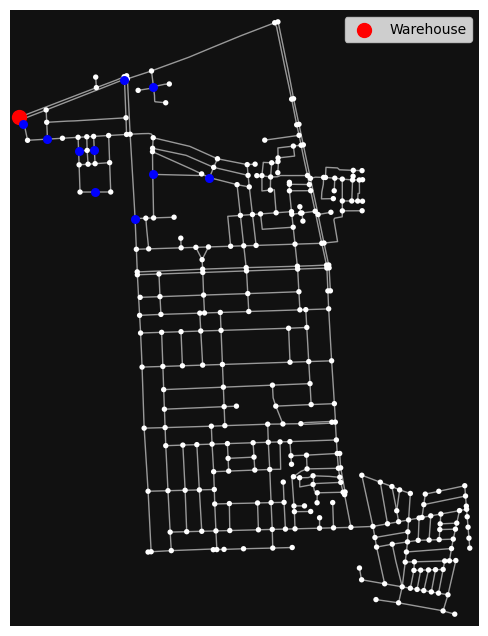

In [5]:
import matplotlib.pyplot as plt

# Plot base graph
fig, ax = ox.plot_graph(G, show=False, close=False)

# Plot warehouse (RED)
x, y = G.nodes[warehouse_node]['x'], G.nodes[warehouse_node]['y']
ax.scatter(x, y, c='red', s=100, label='Warehouse')

# Plot orders (BLUE)
for node in orders:
    x, y = G.nodes[node]['x'], G.nodes[node]['y']
    ax.scatter(x, y, c='blue', s=30)

plt.legend()
plt.show()

In [6]:
# -------------------------------
# STEP 3: Distance Matrix
# -------------------------------

# Combine warehouse + orders
locations = [warehouse_node] + orders

def compute_distance_matrix(G, locations):
    matrix = []

    for i in locations:
        row = []
        for j in locations:
            try:
                length = nx.shortest_path_length(G, i, j, weight='length')
            except:
                length = 1e6  # penalty if no path
            row.append(int(length))
        matrix.append(row)

    return matrix

distance_matrix = compute_distance_matrix(G, locations)

# Print matrix
print("\nDistance Matrix:")
for row in distance_matrix:
    print(row)


Distance Matrix:
[0, 621, 151, 477, 295, 751, 517, 31, 373, 345, 694]
[621, 0, 470, 505, 414, 188, 515, 590, 391, 364, 201]
[151, 470, 0, 326, 144, 600, 511, 120, 367, 193, 543]
[477, 505, 326, 0, 181, 635, 614, 446, 470, 232, 578]
[295, 414, 144, 181, 0, 544, 523, 264, 379, 51, 487]
[751, 188, 600, 635, 544, 0, 645, 720, 520, 493, 389]
[517, 515, 511, 614, 523, 645, 0, 517, 143, 472, 588]
[31, 590, 120, 446, 264, 720, 517, 0, 373, 314, 663]
[373, 391, 367, 470, 379, 520, 143, 373, 0, 328, 463]
[345, 364, 193, 232, 51, 493, 472, 314, 328, 0, 436]
[694, 201, 543, 578, 487, 389, 588, 663, 463, 436, 0]


In [7]:
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# -------------------------------
# STEP 4: OR-Tools Routing
# -------------------------------

num_vehicles = 6   # number of delivery riders
depot = 0          # warehouse index

# Create routing manager
manager = pywrapcp.RoutingIndexManager(len(distance_matrix), num_vehicles, depot)

# Create routing model
routing = pywrapcp.RoutingModel(manager)

# Distance callback
def distance_callback(from_index, to_index):
    return distance_matrix[
        manager.IndexToNode(from_index)][
        manager.IndexToNode(to_index)
    ]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Set cost function
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Solve parameters
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

# Solve problem
solution = routing.SolveWithParameters(search_parameters)

In [8]:
# -------------------------------
# STEP 5: Print solution
# -------------------------------

def print_solution(manager, routing, solution):
    total_distance = 0

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route = []

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route.append(node)

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id)

        route.append(manager.IndexToNode(index))

        print(f"\nVehicle {vehicle_id} route:")
        print(" -> ".join(map(str, route)))
        print(f"Distance: {route_distance} meters")

        total_distance += route_distance

    print(f"\nTotal distance: {total_distance} meters")


if solution:
    print_solution(manager, routing, solution)
else:
    print("No solution found!")


Vehicle 0 route:
0 -> 0
Distance: 0 meters

Vehicle 1 route:
0 -> 0
Distance: 0 meters

Vehicle 2 route:
0 -> 0
Distance: 0 meters

Vehicle 3 route:
0 -> 0
Distance: 0 meters

Vehicle 4 route:
0 -> 0
Distance: 0 meters

Vehicle 5 route:
0 -> 8 -> 6 -> 5 -> 1 -> 10 -> 9 -> 3 -> 4 -> 2 -> 7 -> 0
Distance: 2694 meters

Total distance: 2694 meters


In [9]:
import matplotlib.pyplot as plt

# -------------------------------
# STEP 6: Extract routes
# -------------------------------

def get_routes(manager, routing, solution):
    routes = []

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        route = []

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route.append(node)
            index = solution.Value(routing.NextVar(index))

        route.append(manager.IndexToNode(index))
        routes.append(route)

    return routes

routes = get_routes(manager, routing, solution)

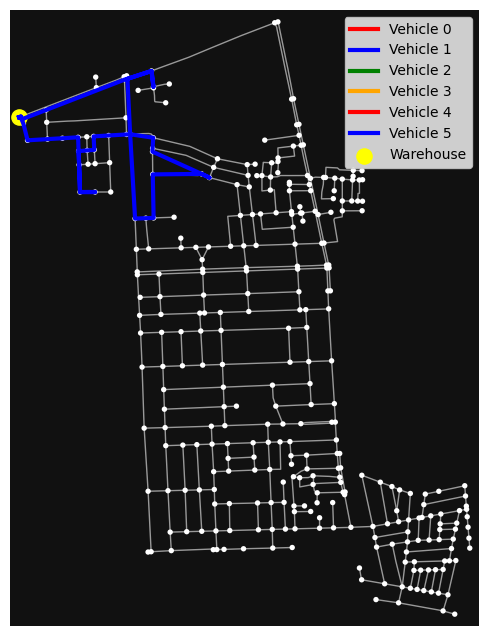

In [10]:
# -------------------------------
# STEP 7: Plot routes on map
# -------------------------------

colors = ['red', 'blue', 'green', 'orange']

fig, ax = ox.plot_graph(G, show=False, close=False)

for i, route in enumerate(routes):
    route_nodes = []

    for j in range(len(route) - 1):
        start = locations[route[j]]
        end = locations[route[j + 1]]

        # Get shortest path between points
        path = nx.shortest_path(G, start, end, weight='length')
        route_nodes.extend(path)

    # Plot route
    xs = [G.nodes[n]['x'] for n in route_nodes]
    ys = [G.nodes[n]['y'] for n in route_nodes]

    ax.plot(xs, ys, color=colors[i % len(colors)], linewidth=3, label=f'Vehicle {i}')

# Plot warehouse
wx, wy = G.nodes[warehouse_node]['x'], G.nodes[warehouse_node]['y']
ax.scatter(wx, wy, c='yellow', s=120, label='Warehouse')

plt.legend()
plt.show()

In [11]:
# -------------------------------
# STEP 8: Random Route Generation
# -------------------------------

import random

def generate_random_routes(locations, num_vehicles):
    nodes = list(range(1, len(locations)))  # exclude depot (0)
    random.shuffle(nodes)

    split = len(nodes) // num_vehicles
    routes = []

    for i in range(num_vehicles):
        route = [0]  # start at warehouse
        route += nodes[i*split:(i+1)*split]
        route.append(0)  # return to warehouse
        routes.append(route)

    return routes

random_routes = generate_random_routes(locations, num_vehicles)

In [12]:
# -------------------------------
# STEP 9: Distance Calculation
# -------------------------------

def calculate_route_distance(route, distance_matrix):
    distance = 0
    for i in range(len(route) - 1):
        distance += distance_matrix[route[i]][route[i+1]]
    return distance


def total_distance(routes, distance_matrix):
    return sum(calculate_route_distance(r, distance_matrix) for r in routes)

In [13]:
optimized_routes = routes  # from earlier

In [14]:
opt_distance = total_distance(optimized_routes, distance_matrix)
rand_distance = total_distance(random_routes, distance_matrix)

improvement = ((rand_distance - opt_distance) / rand_distance) * 100

print("\n--- Comparison ---")
print(f"Optimized Distance: {opt_distance} meters")
print(f"Random Distance: {rand_distance} meters")
print(f"Improvement: {improvement:.2f}%")


--- Comparison ---
Optimized Distance: 2694 meters
Random Distance: 5014 meters
Improvement: 46.27%


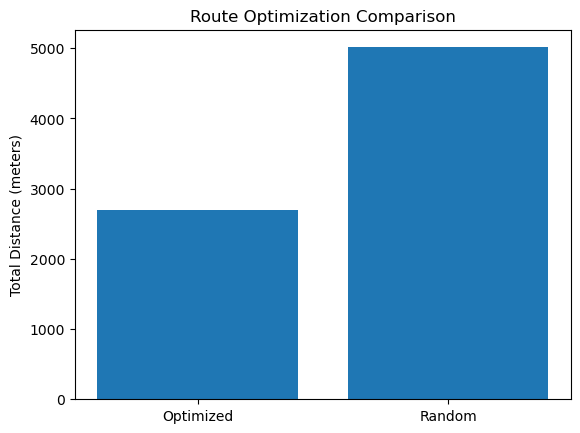

In [15]:
import matplotlib.pyplot as plt

labels = ['Optimized', 'Random']
values = [opt_distance, rand_distance]

plt.bar(labels, values)
plt.title("Route Optimization Comparison")
plt.ylabel("Total Distance (meters)")
plt.show()

In [16]:
# -------------------------------
# STEP 10: Extract coordinates
# -------------------------------

import pandas as pd

data = []

for i, node in enumerate(locations):
    lat = G.nodes[node]['y']
    lon = G.nodes[node]['x']

    if i == 0:
        point_type = "Warehouse"
    else:
        point_type = f"Order_{i}"

    data.append({
        "ID": i,
        "Type": point_type,
        "Latitude": lat,
        "Longitude": lon
    })

df_locations = pd.DataFrame(data)

print("\nLocation Data:")
print(df_locations)


Location Data:
    ID       Type   Latitude  Longitude
0    0  Warehouse  12.982942  77.637371
1    1    Order_1  12.981271  77.641378
2    2    Order_2  12.982300  77.638224
3    3    Order_3  12.980756  77.639650
4    4    Order_4  12.981950  77.639157
5    5    Order_5  12.981176  77.643077
6    6    Order_6  12.983830  77.641399
7    7    Order_7  12.982748  77.637503
8    8    Order_8  12.984037  77.640531
9    9    Order_9  12.981988  77.639626
10  10   Order_10  12.979981  77.640849


In [17]:
df_locations.to_csv("locations.csv", index=False)

In [18]:
df_matrix = pd.DataFrame(distance_matrix)
print("\nDistance Matrix Table:")
print(df_matrix)


Distance Matrix Table:
     0    1    2    3    4    5    6    7    8    9    10
0     0  621  151  477  295  751  517   31  373  345  694
1   621    0  470  505  414  188  515  590  391  364  201
2   151  470    0  326  144  600  511  120  367  193  543
3   477  505  326    0  181  635  614  446  470  232  578
4   295  414  144  181    0  544  523  264  379   51  487
5   751  188  600  635  544    0  645  720  520  493  389
6   517  515  511  614  523  645    0  517  143  472  588
7    31  590  120  446  264  720  517    0  373  314  663
8   373  391  367  470  379  520  143  373    0  328  463
9   345  364  193  232   51  493  472  314  328    0  436
10  694  201  543  578  487  389  588  663  463  436    0


In [19]:
df_matrix.to_csv("distance_matrix.csv", index=False)

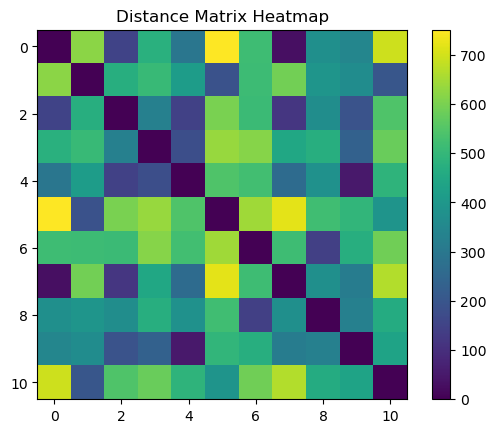

In [20]:
import matplotlib.pyplot as plt

plt.imshow(distance_matrix)
plt.colorbar()
plt.title("Distance Matrix Heatmap")
plt.show()

In [21]:
# -------------------------------
# STEP 11: Generate large dataset
# -------------------------------

import pandas as pd
import random

def generate_large_dataset(G, warehouse_node, num_samples=700, radius=1500):
    data = []

    lengths = nx.single_source_dijkstra_path_length(
        G, warehouse_node, cutoff=radius, weight='length'
    )

    nearby_nodes = list(lengths.keys())

    for i in range(num_samples):
        node = random.choice(nearby_nodes)

        lat = G.nodes[node]['y']
        lon = G.nodes[node]['x']
        distance = lengths[node]

        # Simulated delivery time (based on distance)
        delivery_time = distance / 200 + random.uniform(2, 5)

        # Simulated demand
        demand = random.randint(1, 5)

        data.append({
            "Order_ID": i,
            "Latitude": lat,
            "Longitude": lon,
            "Distance_m": distance,
            "Delivery_Time_min": round(delivery_time, 2),
            "Demand": demand
        })

    return pd.DataFrame(data)

df_large = generate_large_dataset(G, warehouse_node)

print(df_large.head())
print("Total rows:", len(df_large))

   Order_ID   Latitude  Longitude   Distance_m  Delivery_Time_min  Demand
0         0  12.981751  77.645133  1410.810000              10.19       2
1         1  12.977315  77.645788  1415.774154              10.87       2
2         2  12.983910  77.641874   569.545277               5.46       1
3         3  12.980098  77.646333  1390.537361              10.81       3
4         4  12.980164  77.646717  1432.809828              11.85       1
Total rows: 700


In [22]:
df_large.to_csv("large_delivery_data.csv", index=False)

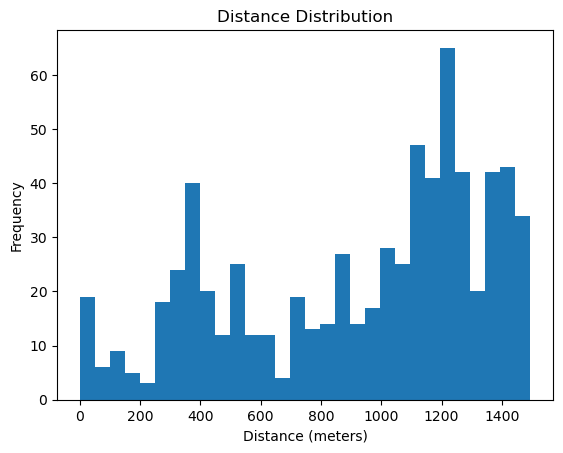

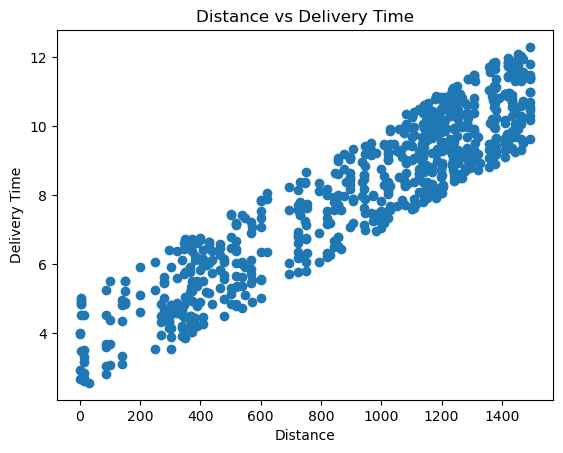

In [23]:
import matplotlib.pyplot as plt

# Distance distribution
plt.hist(df_large["Distance_m"], bins=30)
plt.title("Distance Distribution")
plt.xlabel("Distance (meters)")
plt.ylabel("Frequency")
plt.show()

# Delivery time vs distance
plt.scatter(df_large["Distance_m"], df_large["Delivery_Time_min"])
plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")
plt.show()

In [24]:
# -------------------------------
# STEP: Get building data
# -------------------------------

tags = {'building': True}

buildings = ox.features_from_place(
    "Indiranagar, Bangalore, India",
    tags
)

print("Total buildings:", len(buildings))

Total buildings: 3181


In [25]:
# Step 1: Project to a metric CRS (UTM for Bengaluru)
buildings_proj = buildings.to_crs(epsg=32643)

# Step 2: Compute centroids in projected CRS
buildings_proj['centroid'] = buildings_proj.geometry.centroid

# Step 3: Convert centroids back to lat/lon
centroids_latlon = buildings_proj['centroid'].to_crs(epsg=4326)

# Step 4: Extract coordinates (lat, lon)
building_points = centroids_latlon.apply(lambda p: (p.y, p.x)).tolist()

In [26]:
import random

num_orders = 20
selected_buildings = random.sample(building_points, num_orders)

print("Sample building points:", selected_buildings[:5])

Sample building points: [(12.970662994529276, 77.64974652641679), (12.975320777083835, 77.64571305562602), (12.976066152169139, 77.65166847988783), (12.971896324697619, 77.64668870426871), (12.97216505567919, 77.64292857401891)]


In [27]:
# Convert building coordinates to nearest road nodes
order_nodes = []

for lat, lon in selected_buildings:
    node = ox.distance.nearest_nodes(G, lon, lat)
    order_nodes.append(node)

orders = order_nodes

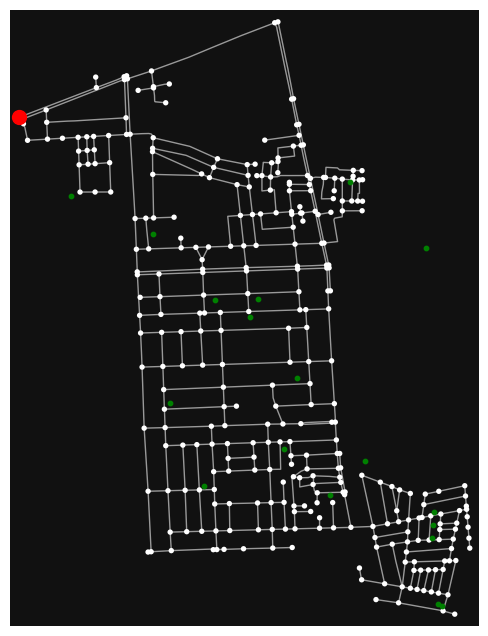

In [28]:
# Plot buildings (green)
fig, ax = ox.plot_graph(G, show=False, close=False)

for lat, lon in selected_buildings:
    ax.scatter(lon, lat, c='green', s=10)

# Warehouse
wx, wy = G.nodes[warehouse_node]['x'], G.nodes[warehouse_node]['y']
ax.scatter(wx, wy, c='red', s=100)

plt.show()

In [29]:
# -------------------------------
# STEP: Filter nearby buildings
# -------------------------------

import shapely.geometry as geom

# Warehouse point
warehouse_point = geom.Point(
    G.nodes[warehouse_node]['x'],
    G.nodes[warehouse_node]['y']
)

# Keep buildings within radius (meters)
radius = 800  # adjust if needed

# Project graph (important for meters)
G_proj = ox.project_graph(G)
buildings_proj = ox.projection.project_gdf(buildings)

# Warehouse in projected CRS
warehouse_proj = geom.Point(
    G_proj.nodes[warehouse_node]['x'],
    G_proj.nodes[warehouse_node]['y']
)

# Filter buildings
nearby_buildings = buildings_proj[
    buildings_proj.geometry.centroid.distance(warehouse_proj) < radius
]

print("Nearby buildings:", len(nearby_buildings))

Nearby buildings: 642


In [30]:
# Convert to centroids
nearby_buildings['centroid'] = nearby_buildings.geometry.centroid

# Convert back to lat/lon
nearby_buildings = nearby_buildings.to_crs("EPSG:4326")

points = nearby_buildings['centroid'].apply(lambda p: (p.y, p.x)).tolist()

# Select orders
num_orders = 12
selected_buildings = random.sample(points, num_orders)

In [31]:
order_nodes = []

for lat, lon in selected_buildings:
    node = ox.distance.nearest_nodes(G, lon, lat)
    order_nodes.append(node)

orders = order_nodes

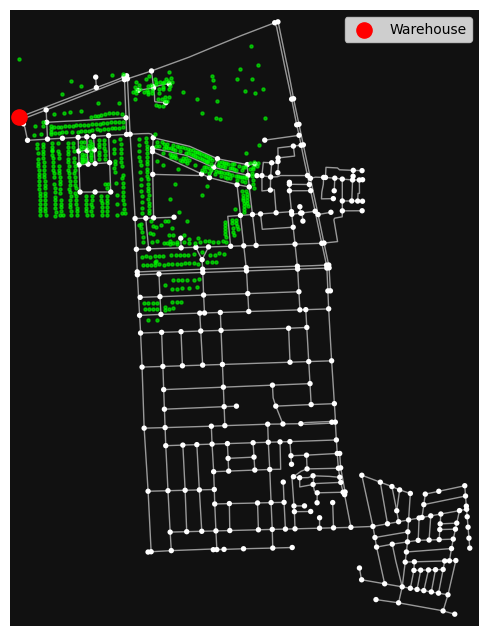

In [32]:
import matplotlib.pyplot as plt

# -------------------------------
# STEP: Plot graph + buildings
# -------------------------------

fig, ax = ox.plot_graph(G, show=False, close=False)

# IMPORTANT: ensure buildings are in lat/lon
nearby_buildings_latlon = nearby_buildings.to_crs("EPSG:4326")

# Plot building centroids
for _, row in nearby_buildings_latlon.iterrows():
    centroid = row.geometry.centroid
    lat, lon = centroid.y, centroid.x
    ax.scatter(lon, lat, c='lime', s=5, alpha=0.6)

# Plot warehouse
wx = G.nodes[warehouse_node]['x']
wy = G.nodes[warehouse_node]['y']
ax.scatter(wx, wy, c='red', s=120, label='Warehouse')

plt.legend()
plt.show()

In [33]:
print("Total buildings:", len(buildings))

Total buildings: 3181


In [34]:
print("Nearby buildings:", len(nearby_buildings))

Nearby buildings: 642


In [35]:
# Create dataset
data = []

for i, row in nearby_buildings_latlon.iterrows():
    centroid = row.geometry.centroid
    lat, lon = centroid.y, centroid.x

    node = ox.distance.nearest_nodes(G, lon, lat)

    try:
        distance = nx.shortest_path_length(G, warehouse_node, node, weight='length')
    except:
        distance = 0

    data.append({
        "Order_ID": len(data),
        "Latitude": lat,
        "Longitude": lon,
        "Distance_m": distance
    })

df_large = pd.DataFrame(data)
print(len(df_large))

642


In [36]:
import random

df_large["Delivery_Time_min"] = df_large["Distance_m"] / 200 + \
    [random.uniform(2, 5) for _ in range(len(df_large))]

df_large["Demand"] = [random.randint(1, 5) for _ in range(len(df_large))]

In [37]:
df_large.to_csv("building_delivery_data.csv", index=False)

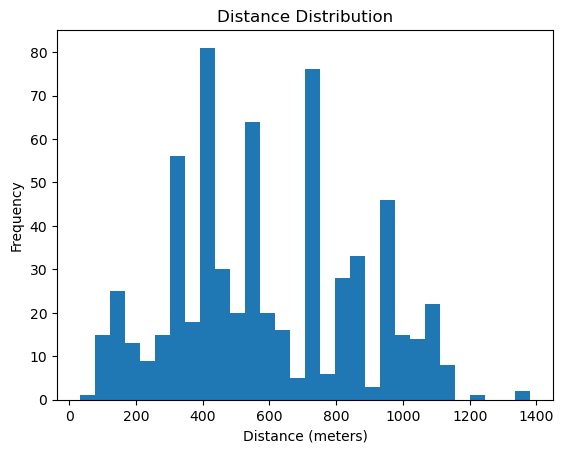

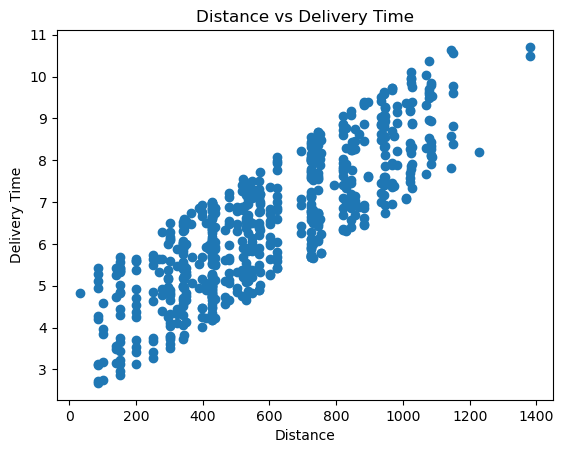

In [38]:
import matplotlib.pyplot as plt

# Distance distribution
plt.hist(df_large["Distance_m"], bins=30)
plt.title("Distance Distribution")
plt.xlabel("Distance (meters)")
plt.ylabel("Frequency")
plt.show()

# Distance vs time
plt.scatter(df_large["Distance_m"], df_large["Delivery_Time_min"])
plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")
plt.show()

In [39]:
sample_df = df_large.sample(40)

orders = []

for _, row in sample_df.iterrows():
    node = ox.distance.nearest_nodes(G, row["Longitude"], row["Latitude"])
    orders.append(node)

In [40]:
# locations = [warehouse_node] + orders
# distance_matrix already computed

num_vehicles = 2
depot = 0  # warehouse index

In [41]:
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# Create manager
manager = pywrapcp.RoutingIndexManager(
    len(distance_matrix),
    num_vehicles,
    depot
)

# Create routing model
routing = pywrapcp.RoutingModel(manager)

In [42]:
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return distance_matrix[from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Set cost (minimize distance)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

In [43]:
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return distance_matrix[from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Set cost (minimize distance)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)


# ✅ ADD HERE
routing.AddDimension(
    transit_callback_index,
    0,          # no slack
    max(max(row) for row in distance_matrix) * 3,       # max distance per vehicle (adjust if needed)
    True,       # start cumul at zero
    "Distance"
)

distance_dimension = routing.GetDimensionOrDie("Distance")

In [44]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()

search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

solution = routing.SolveWithParameters(search_parameters)

In [45]:
def get_routes(manager, routing, solution):
    routes = []

    for vehicle_id in range(num_vehicles):
        index = routing.Start(vehicle_id)
        route = []

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route.append(node)
            index = solution.Value(routing.NextVar(index))

        route.append(manager.IndexToNode(index))
        routes.append(route)

    return routes

routes = get_routes(manager, routing, solution)

In [46]:
def print_solution(routes, distance_matrix):
    total_distance = 0

    for i, route in enumerate(routes):
        route_distance = 0

        for j in range(len(route) - 1):
            route_distance += distance_matrix[route[j]][route[j+1]]

        print(f"Vehicle {i} route: {route}")
        print(f"Distance: {route_distance} meters\n")

        total_distance += route_distance

    print(f"Total Distance: {total_distance} meters")

print_solution(routes, distance_matrix)

Vehicle 0 route: [0, 2, 9, 5, 1, 10, 0]
Distance: 1920 meters

Vehicle 1 route: [0, 7, 4, 3, 8, 6, 0]
Distance: 1606 meters

Total Distance: 3526 meters


In [47]:
import numpy as np

mean_dist = df_large["Distance_m"].mean()
std_dist = df_large["Distance_m"].std()
min_dist = df_large["Distance_m"].min()
max_dist = df_large["Distance_m"].max()

print(mean_dist, std_dist, min_dist, max_dist)

594.8176366416772 273.0148224915097 31.175574673125794 1382.0055903503785


In [48]:
corr = df_large["Distance_m"].corr(df_large["Delivery_Time_min"])
print("Correlation:", corr)

Correlation: 0.8375663320814981


In [49]:
# Demand for each location (0 for warehouse)
demands = [0] + sample_df["Demand"].tolist()

vehicle_capacity = [15, 15]  # capacity per vehicle

def demand_callback(from_index):
    node = manager.IndexToNode(from_index)
    return demands[node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,
    vehicle_capacity,
    True,
    "Capacity"
)

True

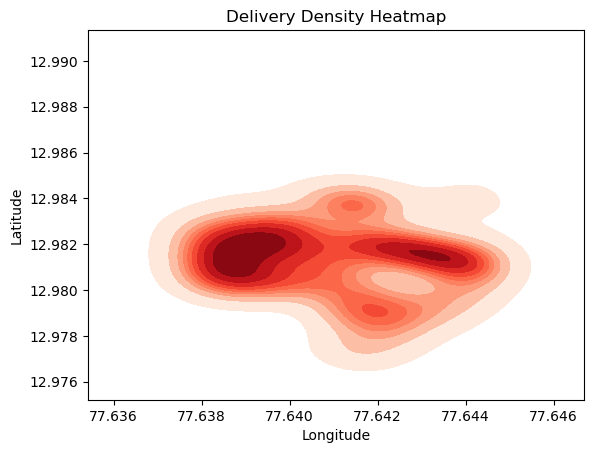

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    x=df_large["Longitude"],
    y=df_large["Latitude"],
    cmap="Reds",
    fill=True,
    thresh=0.05
)

plt.title("Delivery Density Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

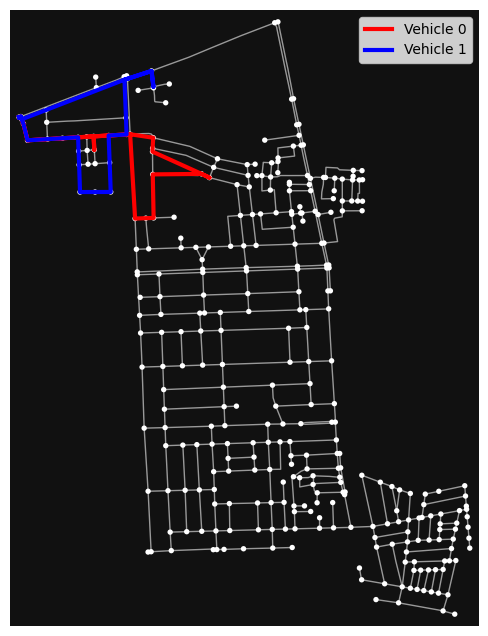

In [51]:
colors = ['red', 'blue', 'green']

fig, ax = ox.plot_graph(G, show=False, close=False)

for i, route in enumerate(routes):
    route_nodes = []

    for j in range(len(route) - 1):
        start = locations[route[j]]
        end = locations[route[j+1]]
        path = nx.shortest_path(G, start, end, weight='length')
        route_nodes.extend(path)

    xs = [G.nodes[n]['x'] for n in route_nodes]
    ys = [G.nodes[n]['y'] for n in route_nodes]

    ax.plot(xs, ys, color=colors[i], linewidth=3, label=f'Vehicle {i}')

plt.legend()
plt.show()

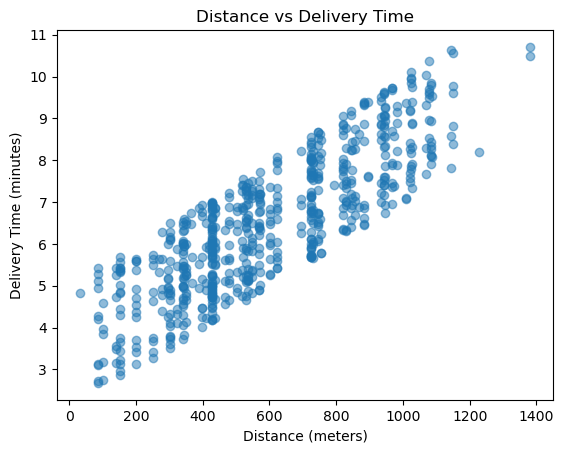

In [52]:
plt.scatter(df_large["Distance_m"], df_large["Delivery_Time_min"], alpha=0.5)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (meters)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

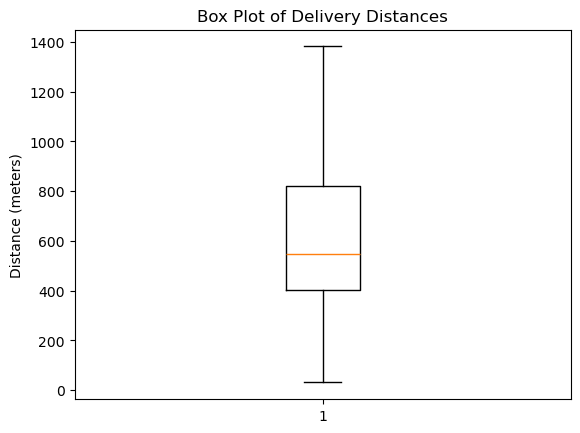

In [53]:
plt.boxplot(df_large["Distance_m"])
plt.title("Box Plot of Delivery Distances")
plt.ylabel("Distance (meters)")
plt.show()

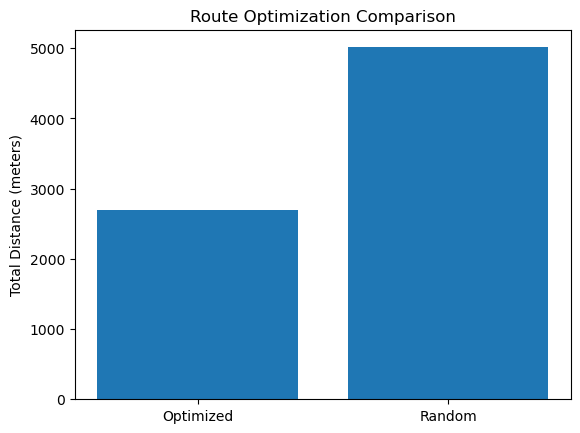

In [54]:
labels = ['Optimized', 'Random']
values = [opt_distance, rand_distance]

plt.bar(labels, values)
plt.title("Route Optimization Comparison")
plt.ylabel("Total Distance (meters)")
plt.show()

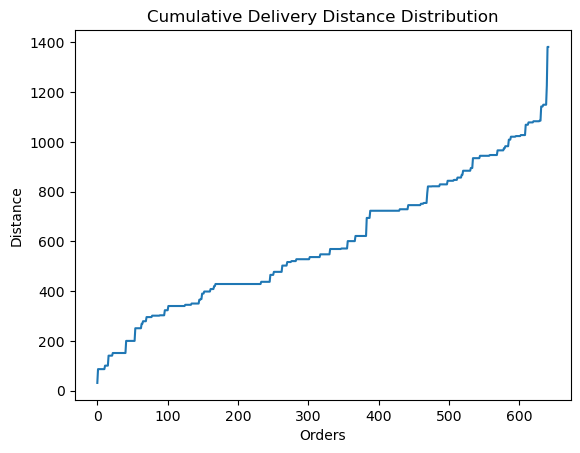

In [55]:
df_large_sorted = df_large.sort_values("Distance_m")

plt.plot(df_large_sorted["Distance_m"].values)
plt.title("Cumulative Delivery Distance Distribution")
plt.xlabel("Orders")
plt.ylabel("Distance")
plt.show()

In [68]:
results = []

for v in [2, 4, 6, 8]:
    num_vehicles = v
    depot = 0

    # Create manager
    manager = pywrapcp.RoutingIndexManager(
        len(distance_matrix),
        num_vehicles,
        depot
    )

    routing = pywrapcp.RoutingModel(manager)

    # Distance callback
    def distance_callback(from_index, to_index):
        return distance_matrix[
            manager.IndexToNode(from_index)][
            manager.IndexToNode(to_index)
        ]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Constraint (FIXED: ensure integer)
    max_distance = int(max(max(row) for row in distance_matrix) * 3)

    routing.AddDimension(
        transit_callback_index,
        0,
        max_distance,
        True,
        "Distance"
    )

    # Solve
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    solution = routing.SolveWithParameters(search_parameters)

    total_distance = 0
    vehicle_distances = []

    if solution:
        for vehicle_id in range(num_vehicles):
            route_distance = 0
            index = routing.Start(vehicle_id)

            while not routing.IsEnd(index):
                previous_index = index
                index = solution.Value(routing.NextVar(index))

                route_distance += routing.GetArcCostForVehicle(
                    previous_index, index, vehicle_id
                )

            vehicle_distances.append(route_distance)
            total_distance += route_distance

        # ✅ STORE RESULT (IMPORTANT FIX)
        results.append((num_vehicles, total_distance, vehicle_distances))

        # ✅ Optional debug print
        print(f"Vehicles: {num_vehicles}")
        print(f"Vehicle distances: {vehicle_distances}")
        print(f"Total distance: {total_distance}\n")

    else:
        print(f"No solution for {num_vehicles} vehicles")

# Final output
print("Final Results:", results)

Vehicles: 2
Vehicle distances: [1920, 1606]
Total distance: 3526

Vehicles: 4
Vehicle distances: [0, 0, 1920, 1606]
Total distance: 3526

Vehicles: 6
Vehicle distances: [0, 0, 0, 0, 1920, 1606]
Total distance: 3526

Vehicles: 8
Vehicle distances: [0, 0, 0, 0, 0, 0, 1920, 1606]
Total distance: 3526

Final Results: [(2, 3526, [1920, 1606]), (4, 3526, [0, 0, 1920, 1606]), (6, 3526, [0, 0, 0, 0, 1920, 1606]), (8, 3526, [0, 0, 0, 0, 0, 0, 1920, 1606])]


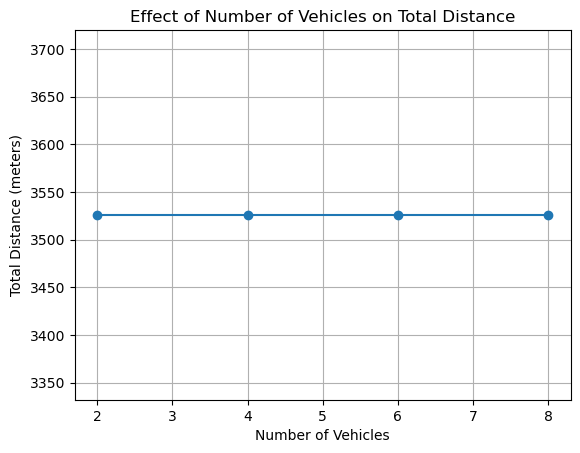

In [69]:
vehicles = [r[0] for r in results]
distances = [r[1] for r in results]

plt.plot(vehicles, distances, marker='o')
plt.title("Effect of Number of Vehicles on Total Distance")
plt.xlabel("Number of Vehicles")
plt.ylabel("Total Distance (meters)")
plt.grid()
plt.show()

In [70]:
mean_dist = df_large["Distance_m"].mean()
std_dist = df_large["Distance_m"].std()

print("Mean distance:", mean_dist)
print("Std deviation:", std_dist)

Mean distance: 594.8176366416772
Std deviation: 273.0148224915097


In [71]:
corr = df_large["Distance_m"].corr(df_large["Delivery_Time_min"])
print("Correlation:", corr)

Correlation: 0.8375663320814981


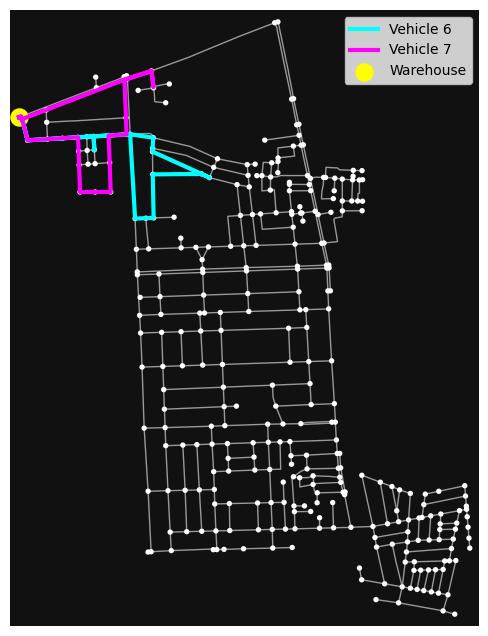

In [72]:

import matplotlib.pyplot as plt

colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta']

fig, ax = ox.plot_graph(G, show=False, close=False)

for vehicle_id in range(num_vehicles):
    index = routing.Start(vehicle_id)

    route_nodes = []

    # Build route
    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route_nodes.append(node)
        index = solution.Value(routing.NextVar(index))

    route_nodes.append(manager.IndexToNode(index))

    # ❌ Skip empty routes
    if len(route_nodes) <= 2:
        continue

    # Convert route into full path
    full_path = []
    for i in range(len(route_nodes) - 1):
        start = locations[route_nodes[i]]
        end = locations[route_nodes[i+1]]

        path = nx.shortest_path(G, start, end, weight='length')
        full_path.extend(path)

    # Plot route
    xs = [G.nodes[n]['x'] for n in full_path]
    ys = [G.nodes[n]['y'] for n in full_path]

    ax.plot(xs, ys, color=colors[vehicle_id % len(colors)], linewidth=3,
            label=f'Vehicle {vehicle_id}')

# Plot warehouse
wx = G.nodes[warehouse_node]['x']
wy = G.nodes[warehouse_node]['y']
ax.scatter(wx, wy, c='yellow', s=150, label='Warehouse')

plt.legend()
plt.show()

In [75]:
import pandas as pd

mean_distance = df_large["Distance_m"].mean()
std_distance = df_large["Distance_m"].std()
min_distance = df_large["Distance_m"].min()
max_distance = df_large["Distance_m"].max()
median_distance = df_large["Distance_m"].median()

# Create table
stats_df = pd.DataFrame({
    "Metric": ["Mean Distance", "Std Deviation", "Minimum Distance", "Maximum Distance", "Median Distance"],
    "Value (meters)": [mean_distance, std_distance, min_distance, max_distance, median_distance]
})

print(stats_df)

             Metric  Value (meters)
0     Mean Distance      594.817637
1     Std Deviation      273.014822
2  Minimum Distance       31.175575
3  Maximum Distance     1382.005590
4   Median Distance      548.162025


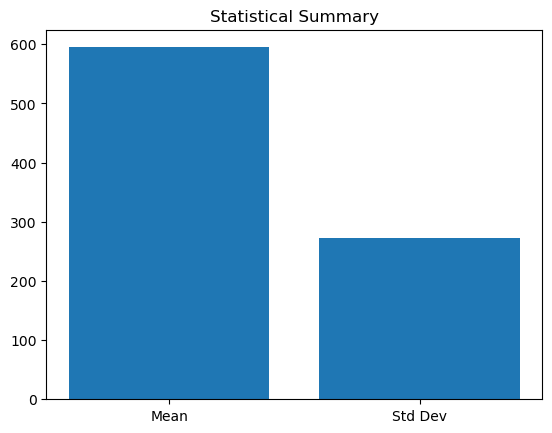

In [76]:
plt.bar(["Mean", "Std Dev"], [mean_distance, std_distance])
plt.title("Statistical Summary")
plt.show()